In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [ ]:
cleaned_data= pd.read_csv('/content/drive/MyDrive/raw_wide_cleaned_cities.csv')
cleaned_data.head()

,Unnamed: 0,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name
0,0,2016-01-23 03:15:00+00:00,IN,Delhi,Income Tax Office,28.623500,77.249400,NaN,NaN,NaN,NaN,28.0,90.0,2,CPCB
1,1,2016-02-09 20:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network
2,2,2016-02-09 20:00:00+00:00,GB,London,Haringey Roadside,51.507446,-0.127765,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA
3,3,2016-02-16 18:00:00+00:00,CL,Llayllay,Los Vientos,-40.801776,-73.219064,NaN,57.87,NaN,432.562,NaN,740.7,4,Chile - SINCA
4,4,2016-02-19 01:00:00+00:00,TH,Loei,"Na An, Mueang",17.315856,101.463828,NaN,NaN,NaN,NaN,NaN,801.5,1,Thailand


In [ ]:
# Drop the accidental index column
if 'Unnamed: 0' in cleaned_data.columns:
    cleaned_data = cleaned_data.drop(columns=['Unnamed: 0'])
cleaned_data.head(2)

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name
0,2016-01-23 03:15:00+00:00,IN,Delhi,Income Tax Office,28.623500,77.249400,NaN,NaN,NaN,NaN,28.0,90.0,2,CPCB
1,2016-02-09 20:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network


SPLITTING DATA

In [ ]:
# Check the start and end time for the FIRST 5 cities in list
for city in cleaned_data['region_name'].unique()[:5]:
    subset = cleaned_data[cleaned_data['region_name'] == city]
    print(f"City: {city}")
    print(f"  > Rows: {len(subset)}")
    print(f"  > Start: {subset['timestamp'].min()}")
    print(f"  > End:   {subset['timestamp'].max()}")
    print("-" * 20)

City: Delhi
  > Rows: 16644
  > Start: 2016-01-23 03:15:00+00:00
  > End:   2022-05-26 17:30:00+00:00
--------------------
City: Haringey
  > Rows: 345
  > Start: 2016-02-09 20:00:00+00:00
  > End:   2022-05-26 16:00:00+00:00
--------------------
City: London
  > Rows: 16895
  > Start: 2016-02-09 20:00:00+00:00
  > End:   2022-05-26 17:00:00+00:00
--------------------
City: Llayllay
  > Rows: 1
  > Start: 2016-02-16 18:00:00+00:00
  > End:   2016-02-16 18:00:00+00:00
--------------------
City: Loei
  > Rows: 1356
  > Start: 2016-02-19 01:00:00+00:00
  > End:   2022-05-26 17:00:00+00:00
--------------------


In [ ]:
df_split = cleaned_data.copy()


=== DATA DISTRIBUTION BY YEAR ===
Year   |         Rows | % of Total
-----------------------------------
2016   |          587 |       0.0%
2017   |          814 |       0.0%
2018   |        1,086 |       0.0%
2019   |          874 |       0.0%
2020   |        7,210 |       0.3%
2021   |        1,180 |       0.0%
2022   |    2,408,649 |      99.5%
-----------------------------------


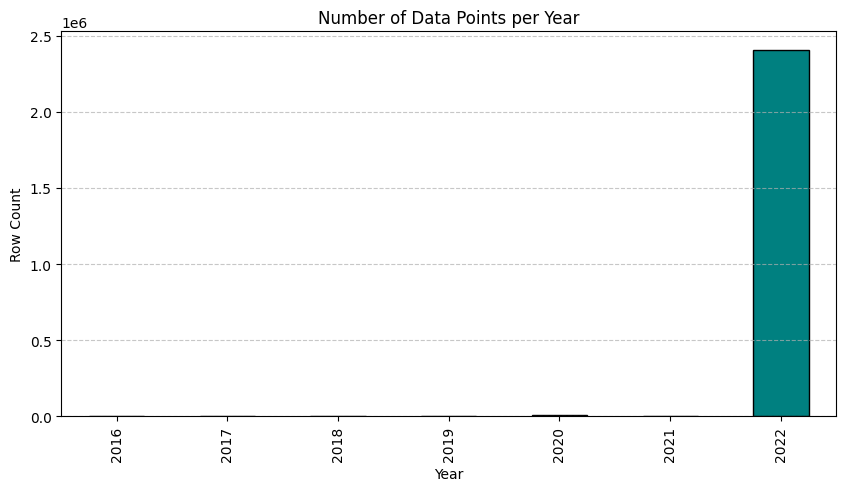

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp is datetime
df_split['timestamp'] = pd.to_datetime(df_split['timestamp'])

#  Calculate Rows Per Year
yearly_counts = df_split['timestamp'].dt.year.value_counts().sort_index()

#  Calculate Percentage
yearly_pct = (yearly_counts / len(df_split)) * 100

#  Display Table
print("\n=== DATA DISTRIBUTION BY YEAR ===")
print(f"{'Year':<6} | {'Rows':>12} | {'% of Total':>10}")
print("-" * 35)
for year, count in yearly_counts.items():
    pct = yearly_pct[year]
    print(f"{year:<6} | {count:12,} | {pct:9.1f}%")
print("-" * 35)

#  Quick Bar Chart (Visual Confirmation)
plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Number of Data Points per Year')
plt.xlabel('Year')
plt.ylabel('Row Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd

df_split['timestamp'] = pd.to_datetime(df_split['timestamp']).dt.tz_localize(None)

#  DEFINE THE CUTOFF (1 week future simulation)
cutoff_date = pd.Timestamp('2022-05-20')

print(f"Splitting data at: {cutoff_date}")

#  PERFORM THE TIME SPLIT
df_history = df_split[df_split['timestamp'] < cutoff_date].copy()
df_future  = df_split[df_split['timestamp'] >= cutoff_date].copy()

# VERIFY THE SPLIT
print("-" * 40)
print(f" SPLIT COMPLETE")
print(f"1. df_history (Train/Dev):   {len(df_history):,} rows")
print(f"   (Range: {df_history['timestamp'].min()} to {df_history['timestamp'].max()})")
print(f"2. df_future (Test/Sim):     {len(df_future):,} rows")
print(f"   (Range: {df_future['timestamp'].min()} to {df_future['timestamp'].max()})")
print("-" * 40)

# Check that we didn't lose any cities in the future set
print(f"Unique Cities in History: {df_history['station_name'].nunique()}")
print(f"Unique Cities in Future:  {df_future['station_name'].nunique()}")

Splitting data at: 2022-05-20 00:00:00
----------------------------------------
 SPLIT COMPLETE
1. df_history (Train/Dev):   2,155,284 rows
   (Range: 2016-01-23 03:15:00 to 2022-05-19 23:45:00)
2. df_future (Test/Sim):     265,116 rows
   (Range: 2022-05-20 00:00:00 to 2022-05-26 18:00:00)
----------------------------------------
Unique Cities in History: 8739
Unique Cities in Future:  6066


In [ ]:
df_history.head()

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name
0,2016-01-23 03:15:00,IN,Delhi,Income Tax Office,28.623500,77.249400,NaN,NaN,NaN,NaN,28.0,90.0,2,CPCB
1,2016-02-09 20:00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network
2,2016-02-09 20:00:00,GB,London,Haringey Roadside,51.507446,-0.127765,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA
3,2016-02-16 18:00:00,CL,Llayllay,Los Vientos,-40.801776,-73.219064,NaN,57.87,NaN,432.562,NaN,740.7,4,Chile - SINCA
4,2016-02-19 01:00:00,TH,Loei,"Na An, Mueang",17.315856,101.463828,NaN,NaN,NaN,NaN,NaN,801.5,1,Thailand


AQI CALCULATION

In [ ]:
import pandas as pd
import numpy as np
breakpoints = {
    'PM2.5 (µg/m³)': [
        (0.0,     12.0,   0, 50),
        (12.001,  35.4,  51, 100),
        (35.401,  55.4, 101, 150),
        (55.401, 150.4, 151, 200),
        (150.401, 250.4, 201, 300),
        (250.401, 350.4, 301, 400),
        (350.401, 500.4, 401, 500)
    ],

    'PM10 (µg/m³)': [
        (0.0,     54.0,   0, 50),
        (54.001, 154.0,  51, 100),
        (154.001, 254.0, 101, 150),
        (254.001, 354.0, 151, 200),
        (354.001, 424.0, 201, 300),
        (424.001, 504.0, 301, 400),
        (504.001, 604.0, 401, 500)
    ],

    # NO2 (1-hour) -> Table 5 says 0-53 ppb, 54-100 ppb...
    # Factor: 1.88
    'NO2 (µg/m³)': [
        (0.0,      99.64,   0, 50),   # 53 * 1.88 = 99.64
        (99.641,   188.0,  51, 100),  # 100 * 1.88 = 188.0
        (188.001,  676.8, 101, 150),  # 360 * 1.88 = 676.8
        (676.801,  1220.1, 151, 200), # 649 * 1.88 = 1220.12
        (1220.101, 2348.1, 201, 300), # 1249 * 1.88 = 2348.12
        (2348.101, 3100.1, 301, 400), # 1649 * 1.88 = 3100.12
        (3100.101, 3852.1, 401, 500)  # 2049 * 1.88 = 3852.12
    ],

    # SO2 (1-hour) -> Table 5 says 0-35 ppb, 36-75 ppb...
    # Factor: 2.62
    'SO2 (µg/m³)': [
        (0.0,       91.7,   0, 50),   # 35 * 2.62 = 91.7
        (91.701,   196.5,  51, 100),  # 75 * 2.62 = 196.5
        (196.501,  484.7, 101, 150),  # 185 * 2.62 = 484.7
        (484.701,  796.5, 151, 200),  # 304 * 2.62 = 796.48
        (796.501, 1582.5, 201, 300),  # 604 * 2.62 = 1582.48
        (1582.501, 2106.5, 301, 400), # 804 * 2.62 = 2106.48
        (2106.501, 2630.5, 401, 500)  # 1004 * 2.62 = 2630.48
    ],

    # CO (8-hour) -
    # Factor: 1145 (since 1 ppm = 1.145 mg/m3 = 1145 ug/m3)
    'CO (µg/m³)': [
        (0.0,       5038.0,   0, 50),   # 4.4 * 1145 = 5038
        (5038.001, 10763.0,  51, 100),  # 9.4 * 1145 = 10763
        (10763.001, 14198.0, 101, 150), # 12.4 * 1145 = 14198
        (14198.001, 17633.0, 151, 200), # 15.4 * 1145 = 17633
        (17633.001, 34808.0, 201, 300), # 30.4 * 1145 = 34808
        (34808.001, 46258.0, 301, 400), # 40.4 * 1145 = 46258
        (46258.001, 57708.0, 401, 500)  # 50.4 * 1145 = 57708
    ],

    # Ozone (8-hour)
    # Factor: 1960 (since 1 ppm = 1000 ppb; 1000 * 1.96 = 1960)
    'O3 (µg/m³)': [
        (0.0,      105.8,   0, 50),   # 0.054 * 1960 = 105.84
        (105.801,  137.2,  51, 100),  # 0.070 * 1960 = 137.2
        (137.201,  166.6, 101, 150),  # 0.085 * 1960 = 166.6
        (166.601,  205.8, 151, 200),  # 0.105 * 1960 = 205.8
        (205.801,  392.0, 201, 300)   # 0.200 * 1960 = 392.0
    ]
}

# CALCULATE AQI SUB-INDICES
import numpy as np

def calculate_sub_index_fast(series, pollutant_name):
    """
    Super-fast Numpy implementation of AQI calc.
    5x-10x faster than Pandas .apply() or standard masking.
    """
    vals = series.to_numpy(dtype=float)

    # Pre-allocate result array with NaNs
    aqi_result = np.full(len(vals), np.nan)

    #  Get breakpoints
    bp_list = breakpoints.get(pollutant_name, [])

    # Loop through ranges using raw array masking
    for (low_c, high_c, low_i, high_i) in bp_list:
        # Create boolean mask
        mask = (vals >= low_c) & (vals <= high_c)

        # Only calculate if matches exist
        if np.any(mask):
            slope = (high_i - low_i) / (high_c - low_c)
            # Direct numpy array math
            aqi_result[mask] = slope * (vals[mask] - low_c) + low_i

    #  Handle "Beyond Index"
    if bp_list:
        max_c = bp_list[-1][1]
        mask_high = vals > max_c
        if np.any(mask_high):
            aqi_result[mask_high] = 500.0

    return aqi_result

# EXECUTION
print("1. Calculating Sub-Indices (Turbo Mode)...")
df_aqi = df_history.copy()
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']
sub_index_cols = []

# Loop through columns and apply the fast function
for col in pollutant_cols:
    if col in df_aqi.columns:
        print(f"  -> Processing {col}...")
        si_col_name = f"{col.split(' ')[0]}_Idx"

        # CALL THE NEW FAST FUNCTION
        df_aqi[si_col_name] = calculate_sub_index_fast(df_aqi[col], col)

        sub_index_cols.append(si_col_name)

# Max Calculation
df_aqi['AQI_Value'] = df_aqi[sub_index_cols].max(axis=1)
print("Sub-Indices Calculated.")


#  ASSIGN CATEGORIES
print("3. Assigning Categories...")
bins = [-1, 50, 100, 150, 200, 300, float('inf')]

# Define the corresponding labels
labels = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

df_aqi['AQI_Category'] = pd.cut(df_aqi['AQI_Value'], bins=bins, labels=labels)

# Handle NaNs (if any AQI was NaN, fill with 'Unknown')
df_aqi['AQI_Category'] = df_aqi['AQI_Category'].cat.add_categories('Unknown').fillna('Unknown')

print(" Categories Assigned.")



1. Calculating Sub-Indices (Turbo Mode)...
  -> Processing PM2.5 (µg/m³)...
  -> Processing PM10 (µg/m³)...
  -> Processing NO2 (µg/m³)...
  -> Processing SO2 (µg/m³)...
  -> Processing O3 (µg/m³)...
  -> Processing CO (µg/m³)...
Sub-Indices Calculated.
3. Assigning Categories...
 Categories Assigned.


In [ ]:
# Removing Unknown columns
df_aqi = df_aqi[df_aqi['AQI_Category'] != 'Unknown'].copy()
df_aqi['AQI_Category'].value_counts()

,count
AQI_Category,
Good,1648125
Moderate,327815
Unhealthy for Sensitive Groups,62907
Unhealthy,57020
Very Unhealthy,9900
Hazardous,6154
Unknown,0


In [ ]:
df_aqi.isna().sum()

,0
timestamp,0
country,0
region_name,0
station_name,0
latitude,0
longitude,0
PM2.5 (µg/m³),1101479
PM10 (µg/m³),1253366
NO2 (µg/m³),1224106
SO2 (µg/m³),1606891


In [ ]:
# Drop the intermediate sub-index columns if you don't want them
cols_to_drop = ['PM2.5_Idx', 'PM10_Idx', 'NO2_Idx', 'SO2_Idx', 'O3_Idx', 'CO_Idx']
df_aqi.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(" Cleaned up sub-index columns.")

 Cleaned up sub-index columns.


In [ ]:
df_aqi.tail()

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,AQI_Value,AQI_Category
2155279,2022-05-19 23:45:00,IN,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",26.802300,84.507400,NaN,NaN,NaN,NaN,32.30,NaN,1,caaqm,15.264650,Good
2155280,2022-05-19 23:45:00,IN,Motihari,"Gandak Colony, Motihari - BSPCB",26.650689,84.911465,NaN,NaN,NaN,NaN,84.80,NaN,1,caaqm,40.075614,Good
2155281,2022-05-19 23:45:00,IN,Navi Mumbai,"Mahape, Navi Mumbai - MPCB",19.030826,73.019854,73.0,NaN,NaN,24.64,30.83,NaN,3,caaqm,160.077474,Unhealthy
2155282,2022-05-19 23:45:00,IN,Davanagere,"Devaraj Urs Badavane, Davanagere - KSPCB",14.255883,75.830342,NaN,NaN,NaN,NaN,NaN,480.0,1,caaqm,4.763795,Good
2155283,2022-05-19 23:45:00,IN,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",19.877263,75.339024,45.0,166.0,37.5,13.20,30.30,NaN,5,caaqm,124.518726,Unhealthy for Sensitive Groups


EXPLORATORY DATA ANALYSIS

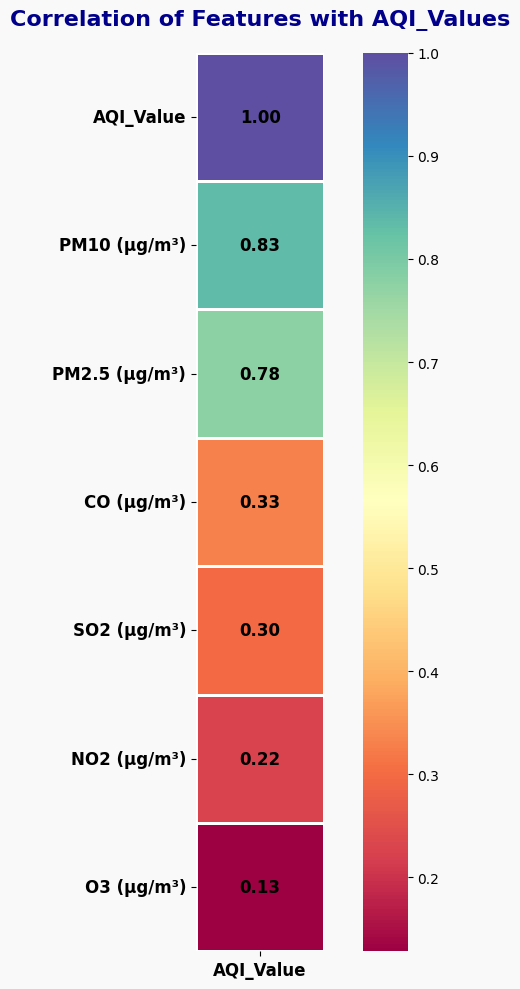

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select only numeric columns relevant to pollution
numeric_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
                'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'AQI_Value',]

# Correlation with dependent variable (CCME_Values)
corr = df_aqi[numeric_cols].corr()['AQI_Value'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 10), facecolor="#f9f9f9")

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="Spectral",
    cbar=True,
    fmt=".2f",
    annot_kws={"size": 12, "weight": "bold", "color": "black"},
    linewidths=0.8,
    linecolor="white",
    square=True
)

# Titles and labels styling
plt.title(
    "Correlation of Features with AQI_Values",
    fontsize=16,
    fontweight="bold",
    color="darkblue",
    pad=20
)

plt.xticks(fontsize=12, weight="bold", color="black")
plt.yticks(fontsize=12, weight="bold", color="black", rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6266/772089555.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df_aqi.groupby('AQI_Category', observed=True).apply(


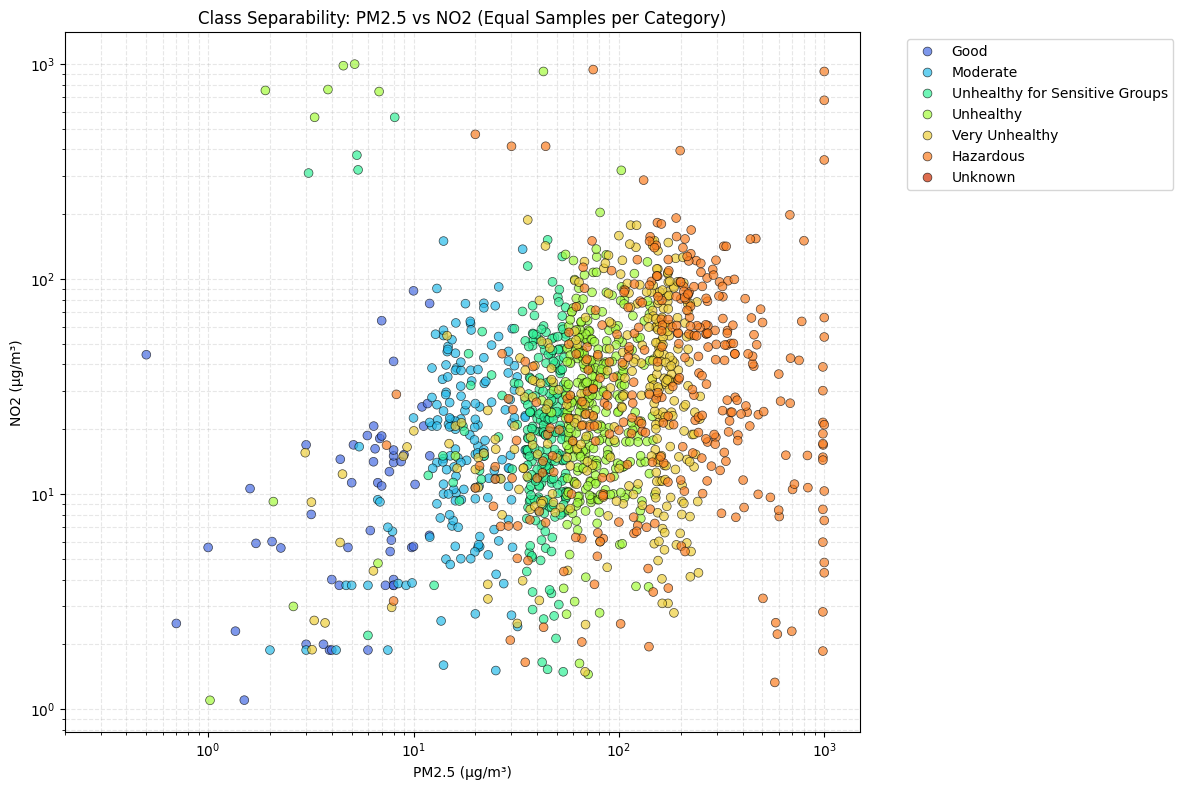

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STRATIFIED SAMPLING FOR CLEAR VISUALIZATION
# ---------------------------------------------------------

# 1. Take 500 random samples from EACH category
# (If a category has less than 500, it takes all of them)
stratified_sample = df_aqi.groupby('AQI_Category', observed=True).apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
).reset_index(drop=True)

# 2. Plot the balanced data
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=stratified_sample,
    x='PM2.5 (µg/m³)',
    y='NO2 (µg/m³)',
    hue='AQI_Category',
    palette='turbo',  # 'turbo' gives very distinct high-contrast colors
    alpha=0.7,
    edgecolor='k',    # Adds a black border to dots for clarity
    s=40              # Slightly larger dots
)

plt.title('Class Separability: PM2.5 vs NO2 (Equal Samples per Category)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

/tmp/ipykernel_6266/1692428013.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


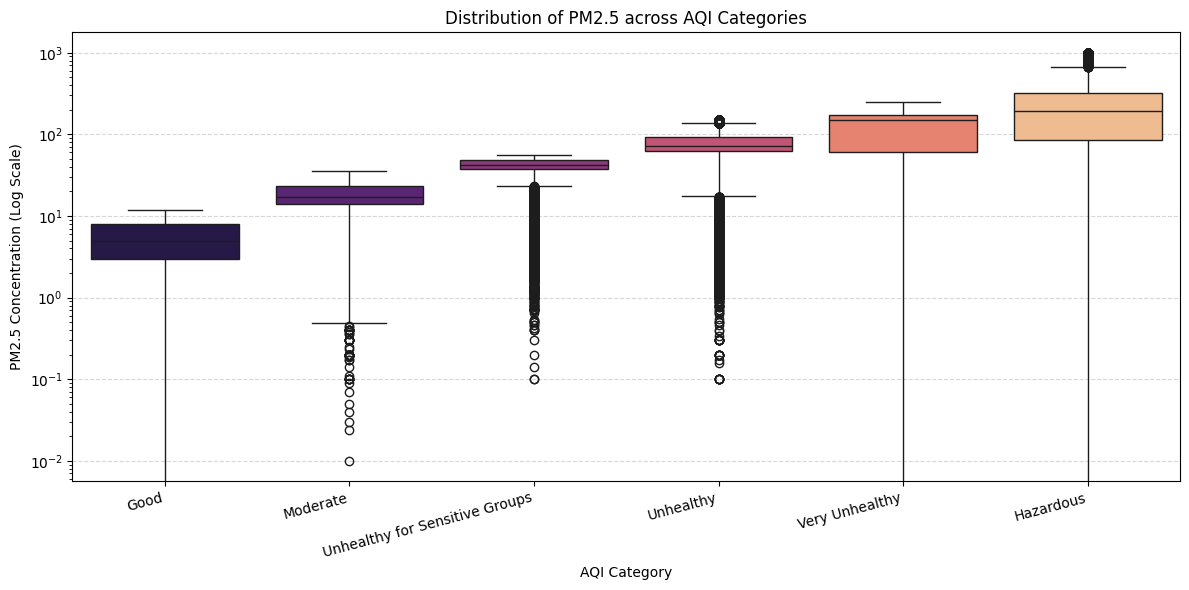

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the valid categories in the correct logical order
valid_categories = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups',
                    'Unhealthy', 'Very Unhealthy', 'Hazardous']

# Filter the dataframe to remove 'Unknown' and only include the categories above
df_filtered = df_aqi[df_aqi['AQI_Category'].isin(valid_categories)]

plt.figure(figsize=(12, 6))

# Use the filtered data and specify the order to ensure it's logical
sns.boxplot(
    data=df_filtered,
    x='AQI_Category',
    y='PM2.5 (µg/m³)',
    order=valid_categories,
    palette='magma'
)

plt.title('Distribution of PM2.5 across AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('PM2.5 Concentration (Log Scale)')
plt.yscale('log')

# Fix overlapping labels by rotating them
plt.xticks(rotation=15, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout() # Ensures everything fits in the frame
plt.show()

MODEL (WITHOUT OPTIMIZATION)

In [ ]:
# SPLITTING AND DEFINING X & y

df_model = df_aqi.sort_values(by=['timestamp']).reset_index(drop=True)

features = [
    # Geography
    'latitude', 'longitude',
    # Pollutants
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)'
]


print(f"Total Features Selected: {len(features)}")

# Define Target
target = 'AQI_Value'

#  Calculate Split (85% Train, 15% Test)
split_index = int(len(df_model) * 0.85)

# Create Train/Test Sets
X_train = df_model.iloc[:split_index][features]
y_train = df_model.iloc[:split_index][target]

X_test = df_model.iloc[split_index:][features]
y_test = df_model.iloc[split_index:][target]

print(f"Training Data (Past):   {X_train.shape}")
print(f"Testing Data (Future):  {X_test.shape}")

Total Features Selected: 8
Training Data (Past):   (1795132, 8)
Testing Data (Future):  (316789, 8)


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TRAIN MODEL - XGBOOST

print("1. Initializing XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("2. Training XGBoost (This might take slightly longer)...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("3. Predicting with XGBoost...")
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("\n--- XGBoost Performance ---")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")

1. Initializing XGBoost...
2. Training XGBoost (This might take slightly longer)...
[0]	validation_0-rmse:43.60475
[100]	validation_0-rmse:6.66441
[200]	validation_0-rmse:6.66077
[300]	validation_0-rmse:6.70687
[400]	validation_0-rmse:6.74589
[500]	validation_0-rmse:6.76284
[600]	validation_0-rmse:6.79862
[700]	validation_0-rmse:6.82110
[800]	validation_0-rmse:6.82963
[900]	validation_0-rmse:6.83327
[999]	validation_0-rmse:6.84487
3. Predicting with XGBoost...

--- XGBoost Performance ---
RMSE: 6.84
MAE:  0.83
